In [2]:
from os import path
import numpy as np
from pathlib import Path
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from tqdm import tqdm
from asbestutills.metrics.rmse import collect_sizes
from asbestutills import Annotation
import itertools
import matplotlib.pyplot as plt

In [24]:
import numpy as np
import itertools
from tqdm import tqdm
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
def read_segmentation_labels(p):
    with open(p, 'r') as f:
        lines = f.readlines()
        return [np.fromstring(line, sep=' ') for line in lines]

In [91]:
### Загружаем набор данных 

In [93]:
#Annotation - структура для работы с разметкой
annotator = Annotation(f"/storage/reshetnikov/rock_other/bench/bench_images/kovsh/annotations/instances_default.json",
                        "/storage/reshetnikov/rock_other/bench/bench_images/kovsh/images/default/")

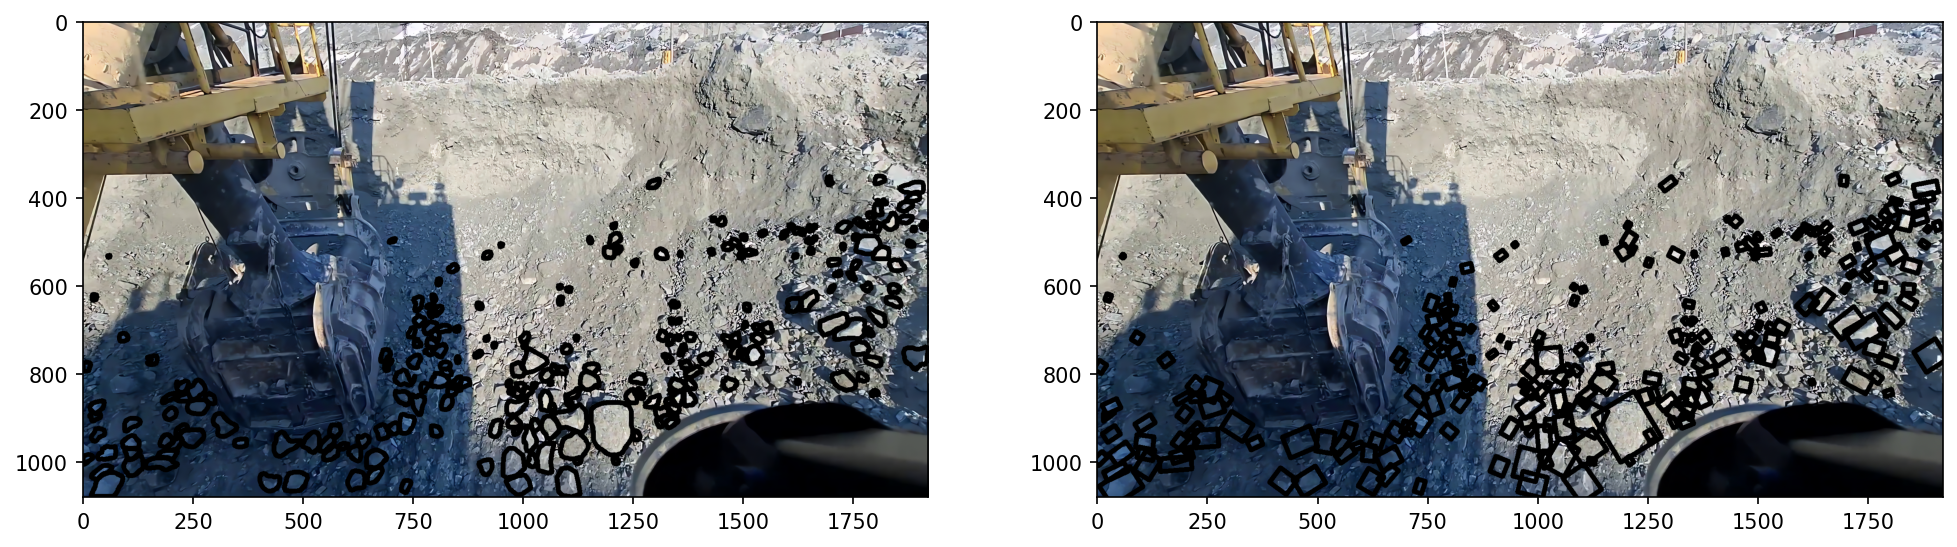

In [94]:
fig, ax = plt.subplots(1,2, dpi = 150, figsize = (16,10))
ax[0].imshow(annotator.get_image_with_contours(14))
ax[1].imshow(annotator.get_image_with_obbox(14))

In [95]:
# Строим словарь: имя файла (без расширения) -> id изображения в аннотации
name_to_id = {}
for img_info in annotator.data_dict()['images']:
    fname = img_info['file_name']   # например "image001"
    fname =  ".".join(Path(fname).name.split('.')[:-1])
    name_to_id[fname] = img_info['id']

### Расчет MAPE для одного изображения

In [97]:
pred_file = Path("./prediction/predict/labels/kovsh_11000.txt")
fname = pred_file.stem
img_id = name_to_id[fname]
print(fname, img_id)
segs = [x['segmentation'] for x in annotator.get_annotations(img_id)]
true_segs = [s[0] for s in segs if len(s) > 0]
pred_segs = read_segmentation_labels(pred_file)   # возвращает список контуров
H, W = annotator.get_image(img_id).shape[:2]
w_true, w_pred = collect_sizes(true_segs, pred_segs, W, H) # собирает размеры из разметки соотвествующие предсказаниям
mape_val = mean_absolute_percentage_error(w_true, w_pred)
print('mape = ', mape_val)

kovsh_11000 14
mape =  0.14405531720661055


### Отрисовка предсказаний

In [98]:
from asbestutills.plotter.plotting import plot_obounding_box

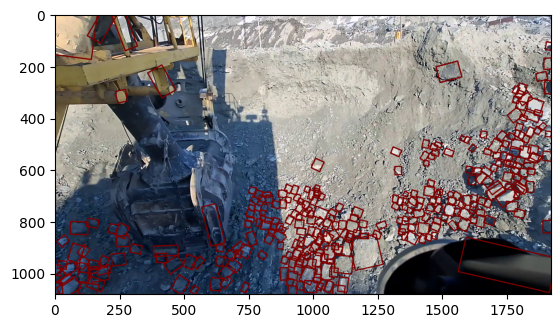

In [99]:
pred_obb = np.array(read_segmentation_labels(pred_file))
pred_obb = pred_obb[:,1:]
img = annotator.get_image(img_id)
img_obbpred = plot_obounding_box(img, pred_obb, 4)
plt.imshow(img_obbpred)

### Основной цикл расчёта ошибок для предсказаний в формате YOLO

In [100]:
path2pred = Path("./prediction/predict/labels/")

# Списки для накопления метрик по этому датасету
mae_list = []           # MAE для каждого предсказания
mape_list = []          # MAPE для каждого предсказания
max_sizes = []          # истинные размеры (из аннотации)
pred_sizes = []         # предсказанные размеры

# 2. Проходим по предсказаниям этого датасета
for pred_file in tqdm(Path(path2pred).glob("*.txt")):
    img_name = pred_file.stem
    img_id = name_to_id[img_name]

    # Получаем сегменты из аннотации (предполагается, что segmentation хранится как список точек)
    segs = [x['segmentation'] for x in annotator.get_annotations(img_id)]
    # Берём первый контур каждого объекта (если есть)
    true_segs = [s[0] for s in segs if len(s) > 0]

    # Предсказанные сегменты (свой формат – функция read_segmentation_labels)
    pred_segs = read_segmentation_labels(pred_file)   # возвращает список контуров

    # Получаем размеры изображения
    try:
        H, W = annotator.get_image(img_id).shape[:2]
        w_true, w_pred = collect_sizes(true_segs, pred_segs, W, H)
    except:
        # print(f"ошибка в {pred_file}")
        continue
    # Собираем размеры (например, ширину или длину) из истинных и предсказанных сегментов
    if len(w_true) == 0:
        continue
    # Вычисляем метрики
    mae_val = mean_absolute_error(w_true, w_pred)
    mape_val = mean_absolute_percentage_error(w_true, w_pred)

    mae_list.append(mae_val)
    mape_list.append(mape_val)
    max_sizes.append(w_true)
    pred_sizes.append(w_pred)


316it [00:34,  9.16it/s]


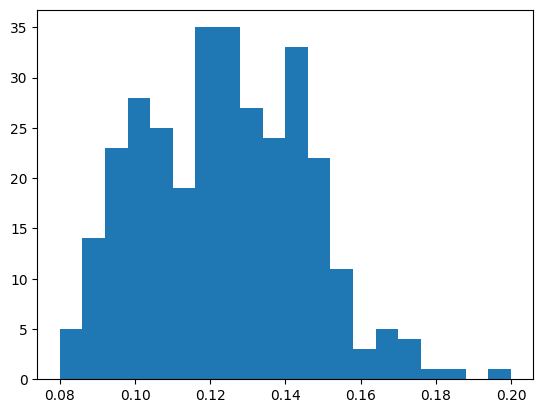

In [101]:
plt.hist(mape_list, 20);